In [52]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt     
import seaborn as sns
import cufflinks as cf
import plotly as pt

In [53]:
df = pd.read_csv("HousingData.csv")
df

,Category,Bedrooms,Bathrooms,SUVs,Cars,Garages,Domestic Help Rooms,Age of House,House Area,Price
0,Premium,2.0,1.0,1.0,1.0,2.0,NaN,15.0,1260.0,16072000.0
1,Luxury,4.0,3.0,2.0,1.0,3.0,3.0,NaN,2400.0,32674000.0
2,Luxury,3.0,2.0,NaN,1.0,3.0,1.0,0.0,2060.0,29660000.0
3,Ultra Luxury,6.0,5.0,3.0,2.0,5.0,2.0,2.0,3880.0,71862000.0
4,Economy,1.0,1.0,0.0,NaN,1.0,1.0,-1.0,310.0,3485000.0
...,...,...,...,...,...,...,...,...,...,...
995,Economy,1.0,1.0,0.0,1.0,1.0,1.0,2.0,310.0,NaN
996,Luxury,4.0,3.0,1.0,1.0,2.0,3.0,-1.0,2310.0,46762000.0
997,Luxury,4.0,3.0,2.0,1.0,3.0,2.0,0.0,2570.0,53195000.0
998,Premium,2.0,1.0,1.0,1.0,2.0,2.0,0.0,1220.0,17591000.0


In [54]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Category             953 non-null    str    
 1   Bedrooms             970 non-null    float64
 2   Bathrooms            891 non-null    float64
 3   SUVs                 932 non-null    float64
 4   Cars                 929 non-null    float64
 5   Garages              942 non-null    float64
 6   Domestic Help Rooms  949 non-null    float64
 7   Age of House         901 non-null    float64
 8   House Area           933 non-null    float64
 9   Price                917 non-null    float64
dtypes: float64(9), str(1)
memory usage: 78.3 KB


In [55]:
df.describe()

,Bedrooms,Bathrooms,SUVs,Cars,Garages,Domestic Help Rooms,Age of House,House Area,Price
count,970.000000,891.000000,932.000000,929.000000,942.000000,949.000000,901.000000,933.000000,9.170000e+02
mean,2.379381,2.138047,0.811159,1.206674,2.027601,1.581665,3.982242,1328.585209,2.134685e+07
std,1.385606,1.328182,0.800620,0.473795,1.095485,0.753977,5.096809,1028.956372,2.038162e+07
min,1.000000,1.000000,0.000000,1.000000,1.000000,0.000000,-2.000000,230.000000,1.553000e+06
25%,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,0.000000,350.000000,3.737000e+06
50%,2.000000,2.000000,1.000000,1.000000,2.000000,1.000000,2.000000,1200.000000,1.663500e+07
75%,3.000000,3.000000,1.000000,1.000000,3.000000,2.000000,8.000000,2040.000000,3.231700e+07
max,6.000000,7.000000,3.000000,3.000000,5.000000,4.000000,15.000000,4280.000000,9.635700e+07


In [56]:
df.isnull().sum()

Category                47
Bedrooms                30
Bathrooms              109
SUVs                    68
Cars                    71
Garages                 58
Domestic Help Rooms     51
Age of House            99
House Area              67
Price                   83
dtype: int64

In [57]:
df.shape

(1000, 10)

How many null values exist in each column?

Remove rows where Age of House is negative.

Replace missing Age of House values with median age.

Check if Bedrooms or Bathrooms contain unrealistic values (like 0 or negative).

Detect and remove duplicate rows.

Convert Category column into consistent format (Premium, Luxury, Economy etc).

In [58]:
df.dropna(inplace=True)

In [59]:
df.shape
# df.isnull().sum()

(486, 10)

In [60]:
df[df['Age of House'] <= 0].shape[0]

163

In [61]:
# df.drop(df[df['Age of House'] < 0].index,inplace=True)
# check negative values
df[df['Age of House'] < 0]

# remove them
df = df[df['Age of House'] >= 0]

In [62]:
df.shape

(384, 10)

In [63]:
df

,Category,Bedrooms,Bathrooms,SUVs,Cars,Garages,Domestic Help Rooms,Age of House,House Area,Price
3,Ultra Luxury,6.0,5.0,3.0,2.0,5.0,2.0,2.0,3880.0,71862000.0
9,Economy,1.0,1.0,0.0,1.0,1.0,1.0,2.0,360.0,3151000.0
10,Premium,2.0,1.0,1.0,1.0,2.0,2.0,12.0,1200.0,16713000.0
12,Economy,1.0,2.0,0.0,1.0,1.0,1.0,8.0,330.0,3605000.0
13,Premium,3.0,2.0,1.0,1.0,2.0,2.0,5.0,1500.0,20637000.0
...,...,...,...,...,...,...,...,...,...,...
982,Premium,2.0,1.0,1.0,1.0,2.0,2.0,15.0,1320.0,17377000.0
988,Premium,3.0,4.0,1.0,1.0,2.0,0.0,0.0,1420.0,33380000.0
991,Luxury,4.0,3.0,1.0,1.0,2.0,2.0,10.0,2400.0,47133000.0
997,Luxury,4.0,3.0,2.0,1.0,3.0,2.0,0.0,2570.0,53195000.0


In [64]:
df['Bedrooms'].value_counts()
df['Bathrooms'].value_counts()
df['SUVs'].value_counts()
df['Cars'].value_counts()
df['Garages'].value_counts()
df['Domestic Help Rooms'].value_counts()
df['Age of House'].value_counts()
df['House Area'].value_counts()
df['Price'].value_counts()
df['Category'].value_counts()


Category
Economy         160
Premium         114
Luxury           67
Ultra Luxury     43
Name: count, dtype: int64

What is the average house price in the dataset?

What is the average house area?

Which category of house is most common?

Which category has the highest average price?

What is the relationship between house area and price?

Do houses with more bedrooms cost more?

Does age of house affect price?

Which category has the largest houses on average?

In [65]:
df['Price'].mean()

np.float64(21324658.854166668)

In [66]:
df

,Category,Bedrooms,Bathrooms,SUVs,Cars,Garages,Domestic Help Rooms,Age of House,House Area,Price
3,Ultra Luxury,6.0,5.0,3.0,2.0,5.0,2.0,2.0,3880.0,71862000.0
9,Economy,1.0,1.0,0.0,1.0,1.0,1.0,2.0,360.0,3151000.0
10,Premium,2.0,1.0,1.0,1.0,2.0,2.0,12.0,1200.0,16713000.0
12,Economy,1.0,2.0,0.0,1.0,1.0,1.0,8.0,330.0,3605000.0
13,Premium,3.0,2.0,1.0,1.0,2.0,2.0,5.0,1500.0,20637000.0
...,...,...,...,...,...,...,...,...,...,...
982,Premium,2.0,1.0,1.0,1.0,2.0,2.0,15.0,1320.0,17377000.0
988,Premium,3.0,4.0,1.0,1.0,2.0,0.0,0.0,1420.0,33380000.0
991,Luxury,4.0,3.0,1.0,1.0,2.0,2.0,10.0,2400.0,47133000.0
997,Luxury,4.0,3.0,2.0,1.0,3.0,2.0,0.0,2570.0,53195000.0


In [68]:
df.drop_duplicates(inplace=True)

In [69]:
df.shape

(383, 10)

In [70]:
df.groupby("Category")["Price"].mean()

Category
Economy         3.593522e+06
Luxury          3.838521e+07
Premium         1.955971e+07
Ultra Luxury    6.539070e+07
Name: Price, dtype: float64

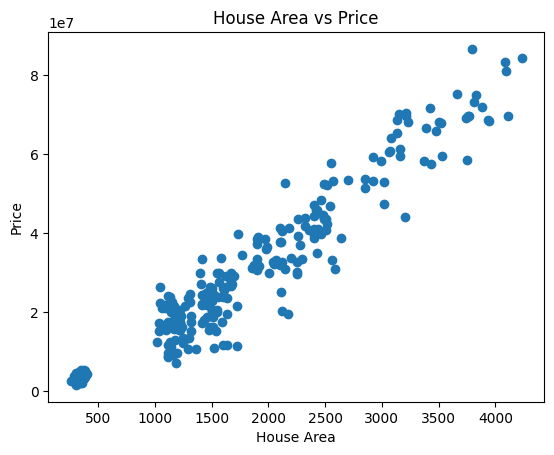

In [ ]:
plt.scatter(df["House Area"], df["Price"])
plt.xlabel("House Area")
plt.ylabel("Price")
plt.title("House Area vs Price")
plt.show()